# Machine Learning Introduction
## Проект: Предсказание арендной цены квартир (Two Sigma Connect)

## 1. Введение (Intro)

**1.1 Пять примеров применения ML в жизни:**

1. **Рекомендательные системы (Netflix, Spotify)** — ML анализирует историю просмотров/прослушиваний и предлагает релевантный контент. Преимущество: персонализация в масштабе миллионов пользователей, невозможная вручную.

2. **Медицинская диагностика по снимкам** — нейросети анализируют рентген/МРТ и выявляют патологии. Преимущество: скорость и точность обнаружения заболеваний на ранней стадии.

3. **Автопилот и беспилотные автомобили (Tesla, Waymo)** — ML обрабатывает данные с камер, лидаров и радаров для навигации. Преимущество: снижение количества ДТП, вызванных человеческим фактором.

4. **Фильтрация спама в email** — классификация писем на спам/не спам на основе текста и метаданных. Преимущество: экономия времени, защита от фишинга.

5. **Кредитный скоринг** — оценка вероятности возврата кредита на основе финансовой истории клиента. Преимущество: быстрое и объективное решение о выдаче кредита.

**1.2 Классификация задач из таблицы и примеров:**

**Из таблицы README:**
1. Predict house price — **Supervised, Regression**
2. Predict loan return — **Supervised, Binary Classification**
3. Predict medicine timing — **Supervised, Regression/Classification**
4. Choose medicine — **Supervised, Multiclass Classification**
5. Choose client segment for promo — **Supervised, Classification** (или Unsupervised Clustering)
6. Recognition of defects — **Supervised, Binary Classification**
7. Product placement — **Supervised, Regression** (или Reinforcement Learning)
8. Search sites — **Supervised, Ranking/Regression**
9. Customer segmentation — **Unsupervised, Clustering**
10. Anomaly detection — **Unsupervised / Semi-supervised, Anomaly Detection**

**Мои 5 примеров:**
1. Рекомендательные системы — **Unsupervised (Clustering/Association)** + Supervised
2. Медицинская диагностика — **Supervised, Binary/Multiclass Classification**
3. Автопилот — **Supervised, Multiclass Classification + Regression**
4. Фильтрация спама — **Supervised, Binary Classification**
5. Кредитный скоринг — **Supervised, Binary Classification / Regression**

**1.3 Разница между multiclass и multilabel:**

- **Multiclass (многоклассовая):** каждый объект принадлежит **ровно одному** классу из множества. Пример: распознавание цифр 0-9 — каждая цифра относится к одному классу.

- **Multilabel (многометочная):** каждый объект может принадлежать **нескольким классам одновременно**. Пример: тегирование фильма — фильм может быть одновременно «комедия», «романтика» и «драма».

**1.4 Является ли пример с ценами на жильё классификацией или регрессией?**

Пример с ценами на жильё — это **задача регрессии**, так как целевая переменная (цена) является непрерывной вещественной величиной.

**Можно ли свести регрессию к классификации?** Да, можно. Например, разбив цены на диапазоны (бины): «дешёвые» (< $100k), «средние» ($100k–$300k), «дорогие» (> $300k) — и предсказывать категорию вместо точной цены. Однако при этом теряется точность прогноза.

## 2. Введение в анализ данных

### 2.1 Импорт библиотек

In [ ]:
# 2.1 Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Все библиотеки успешно импортированы!")

Все библиотеки успешно импортированы!


### 2.2 Загрузка данных

In [2]:
# 2.2 Загрузка данных из train.json
df = pd.read_json("data/train.json")
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,interest_level,latitude,listing_id,longitude,manager_id,photos,price,street_address
0,1.0,0,b2824,2016-04-24 08:15:14,Apartment with 0 bedrooms,143 Street,"[Cats Allowed, No Fee, Parking Space, Laundry ...",medium,40.605959,7000000,-74.006272,m9279,[],2647,617 Avenue
1,4.0,1,b1434,2016-06-07 22:41:44,Apartment with 1 bedrooms,559 Street,"[Elevator, Dishwasher, Fitness Center]",low,40.761886,7000001,-74.048700,m3615,[],3687,715 Avenue
2,2.0,2,b7924,2016-05-09 04:13:48,Apartment with 2 bedrooms,345 Street,[],medium,40.618549,7000002,-74.030657,m6635,[],3501,619 Avenue
3,1.5,0,b5333,2016-04-24 14:34:07,Apartment with 0 bedrooms,997 Street,"[Cats Allowed, No Fee, Fitness Center]",low,40.765881,7000003,-73.926296,m6925,[],3091,592 Avenue
4,1.0,1,b4150,2016-06-03 01:42:14,Apartment with 1 bedrooms,792 Street,"[Cats Allowed, Elevator]",low,40.773297,7000004,-73.973975,m8428,[],2591,651 Avenue


### 2.3 Размер данных

In [3]:
# 2.3 Размер данных (строки и столбцы)
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print(f"Общий размер: {df.shape}")

Количество строк: 49352
Количество столбцов: 15
Общий размер: (49352, 15)


### 2.4 Список столбцов и целевая переменная

In [4]:
# 2.4 Список столбцов
print("Столбцы датасета:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")
print("\nЦелевая переменная — 'price' (цена аренды)")

Столбцы датасета:
  1. bathrooms
  2. bedrooms
  3. building_id
  4. created
  5. description
  6. display_address
  7. features
  8. interest_level
  9. latitude
  10. listing_id
  11. longitude
  12. manager_id
  13. photos
  14. price
  15. street_address

Целевая переменная — 'price' (цена аренды)


### 2.5 Быстрый анализ данных

In [5]:
# 2.5 info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49352 entries, 0 to 49351
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   interest_level   49352 non-null  str    
 8   latitude         49352 non-null  float64
 9   listing_id       49352 non-null  int64  
 10  longitude        49352 non-null  float64
 11  manager_id       49352 non-null  str    
 12  photos           49352 non-null  object 
 13  price            49352 non-null  int64  
 14  street_address   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 5.6+ MB


In [6]:
# describe()
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.000000,49352.000000,49352.000000,4.935200e+04,49352.000000,49352.000000
mean,1.688837,2.064840,40.700319,7.024676e+06,-73.949999,5588.048124
std,1.264977,1.469931,0.057949,1.424684e+04,0.057721,16242.686228
min,0.000000,0.000000,40.600003,7.000000e+06,-74.049995,1518.000000
25%,1.000000,1.000000,40.650075,7.012338e+06,-73.999945,2870.000000
50%,1.000000,2.000000,40.700637,7.024676e+06,-73.950117,3402.000000
75%,2.000000,3.000000,40.750630,7.037013e+06,-73.900205,4118.250000
max,10.000000,8.000000,40.799994,7.049351e+06,-73.850000,199847.000000


In [7]:
# corr() — корреляция числовых столбцов
df.select_dtypes(include='number').corr()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.000062,-0.009862,0.000990,-0.001579,0.027327
bedrooms,0.000062,1.000000,-0.005170,-0.005034,0.002845,0.043114
latitude,-0.009862,-0.005170,1.000000,-0.003530,-0.000964,-0.004177
listing_id,0.000990,-0.005034,-0.003530,1.000000,-0.003132,0.008742
longitude,-0.001579,0.002845,-0.000964,-0.003132,1.000000,-0.006610
price,0.027327,0.043114,-0.004177,0.008742,-0.006610,1.000000


In [8]:
# Проверка на пустые значения
print("Пропуски по столбцам:")
print(df.isnull().sum())
print(f"\nЕсть ли пропуски: {df.isnull().values.any()}")

Пропуски по столбцам:
bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
interest_level     0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
dtype: int64

Есть ли пропуски: False


**Выводы по анализу данных:**
- `info()`: В датасете ~49k записей. Присутствуют числовые (float64, int64) и текстовые (object) типы данных. Пропущенных значений нет.
- `describe()`: Видим выборочную статистику — среднее, медиану, стандартное отклонение, мин/макс и квартили для числовых признаков. Цены имеют большой разброс.
- `corr()`: Наибольшая корреляция между bedrooms и bathrooms (положительная), что логично — больше комнат = больше ванных. Цена коррелирует с обоими признаками.
- Пустых столбцов нет.

### 2.6 Создание DataFrame с 4 столбцами

In [9]:
# 2.6 Оставляем только нужные столбцы
df = df[["bathrooms", "bedrooms", "interest_level", "price"]].copy()
df = df.reset_index(drop=True)
print(f"Новый размер: {df.shape}")
df.head(10)

Новый размер: (49352, 4)


,bathrooms,bedrooms,interest_level,price
0,1.0,0,medium,2647
1,4.0,1,low,3687
2,2.0,2,medium,3501
3,1.5,0,low,3091
4,1.0,1,low,2591
5,1.0,1,low,5032
6,1.0,2,low,3108
7,2.5,0,medium,2765
8,1.5,2,low,2973
9,2.0,2,low,3699


## 3. Статистический анализ данных

### 3.3 Анализ целевой переменной (price)

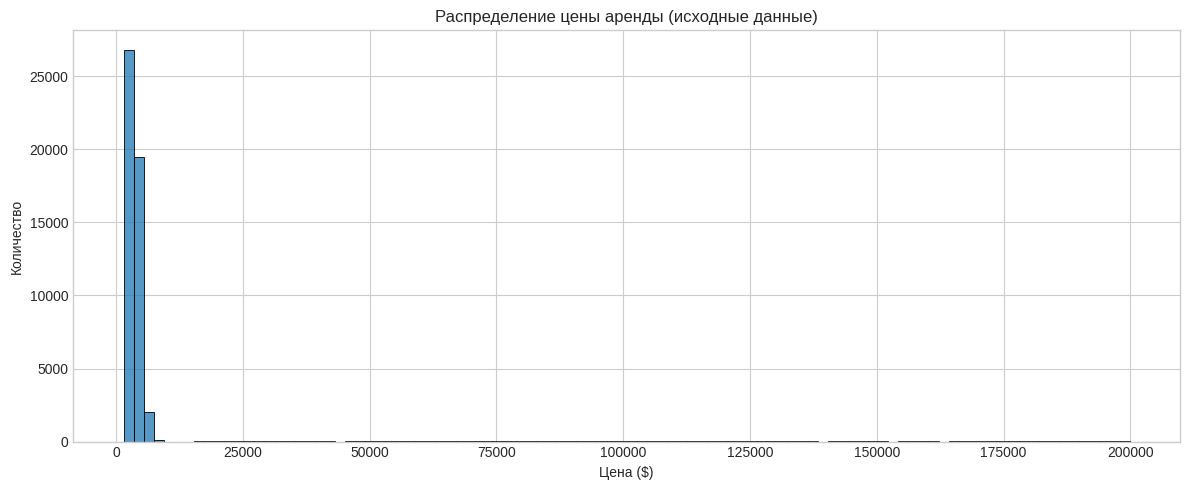

Распределение сильно скошено вправо (right-skewed). Есть экстремальные выбросы, из-за которых основная масса данных сжата в левой части.


In [10]:
# 3.3.1 Гистограмма распределения цены
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=df, x="price", bins=100, ax=ax)
ax.set_title("Распределение цены аренды (исходные данные)")
ax.set_xlabel("Цена ($)")
ax.set_ylabel("Количество")
plt.tight_layout()
plt.show()
print("Распределение сильно скошено вправо (right-skewed). Есть экстремальные выбросы, из-за которых основная масса данных сжата в левой части.")

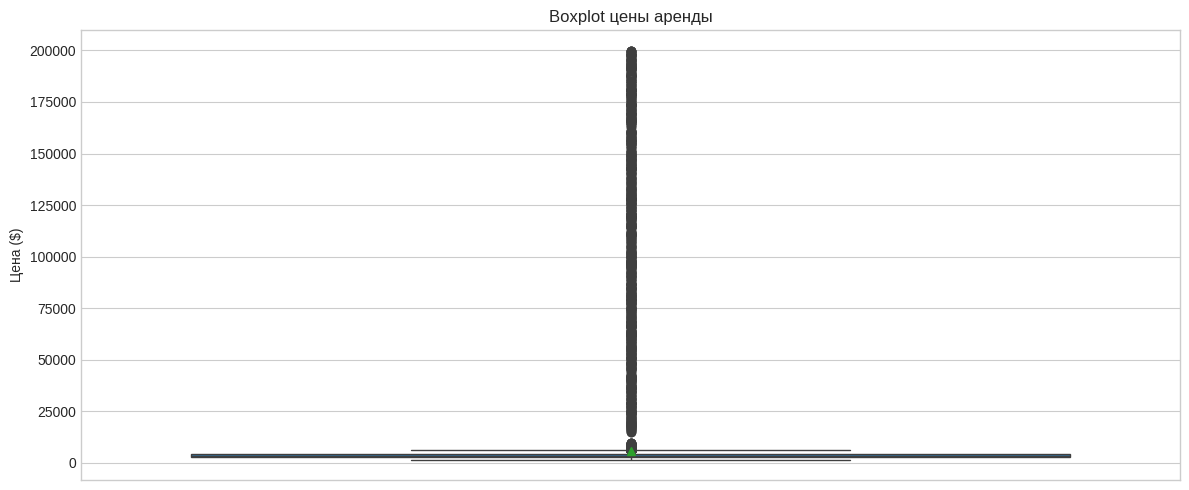

Boxplot показывает наличие множества выбросов (точки выше усов).
Медиана значительно ниже среднего — признак right-skewed распределения.


In [11]:
# 3.3.2 Boxplot для целевой переменной
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(y="price", data=df, showmeans=True, ax=ax)
ax.set_title("Boxplot цены аренды")
ax.set_ylabel("Цена ($)")
plt.tight_layout()
plt.show()
print("Boxplot показывает наличие множества выбросов (точки выше усов).")
print("Медиана значительно ниже среднего — признак right-skewed распределения.")

In [12]:
# 3.3.3 Удаление строк вне 1-го и 99-го процентилей
q01 = df["price"].quantile(0.01)
q99 = df["price"].quantile(0.99)
print(f"1-й процентиль: {q01}")
print(f"99-й процентиль: {q99}")

df = df[(df["price"] >= q01) & (df["price"] <= q99)].reset_index(drop=True)
print(f"\nРазмер после удаления выбросов: {df.shape}")

1-й процентиль: 1893.0
99-й процентиль: 102726.61999999972

Размер после удаления выбросов: (48365, 4)


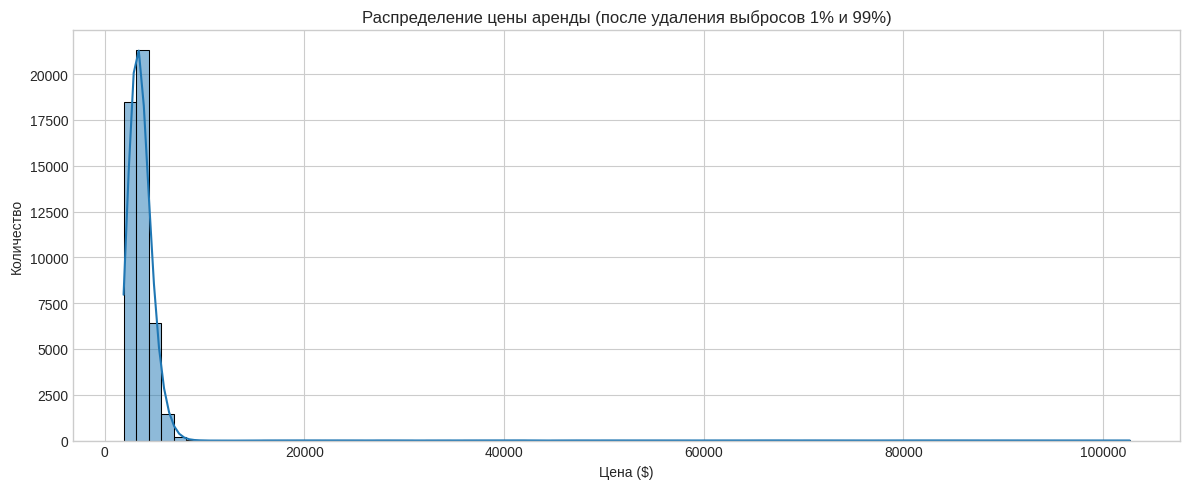

После удаления 2% экстремальных выбросов распределение стало более читаемым.
Видна основная масса цен и характерный правый хвост.


In [13]:
# 3.3.4 Гистограмма после удаления выбросов
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=df, x="price", bins=80, kde=True, ax=ax)
ax.set_title("Распределение цены аренды (после удаления выбросов 1% и 99%)")
ax.set_xlabel("Цена ($)")
ax.set_ylabel("Количество")
plt.tight_layout()
plt.show()
print("После удаления 2% экстремальных выбросов распределение стало более читаемым.")
print("Видна основная масса цен и характерный правый хвост.")

### 3.4 Анализ характеристик

In [14]:
# 3.4.1 Тип столбца interest_level
print(f"Тип столбца 'interest_level': {df['interest_level'].dtype}")

Тип столбца 'interest_level': str


In [15]:
# 3.4.2 Значения и их количество
print("Количество записей по каждому значению:")
print(df["interest_level"].value_counts())

Количество записей по каждому значению:
interest_level
low       33858
medium    10210
high       4297
Name: count, dtype: int64


In [16]:
# 3.4.3 Кодирование interest_level
mapping = {"low": 0, "medium": 1, "high": 2}
df["interest_level"] = df["interest_level"].map(mapping)
print("Кодирование выполнено: low=0, medium=1, high=2")
df.head()

Кодирование выполнено: low=0, medium=1, high=2


,bathrooms,bedrooms,interest_level,price
0,1.0,0,1,2647
1,4.0,1,0,3687
2,2.0,2,1,3501
3,1.5,0,0,3091
4,1.0,1,0,2591


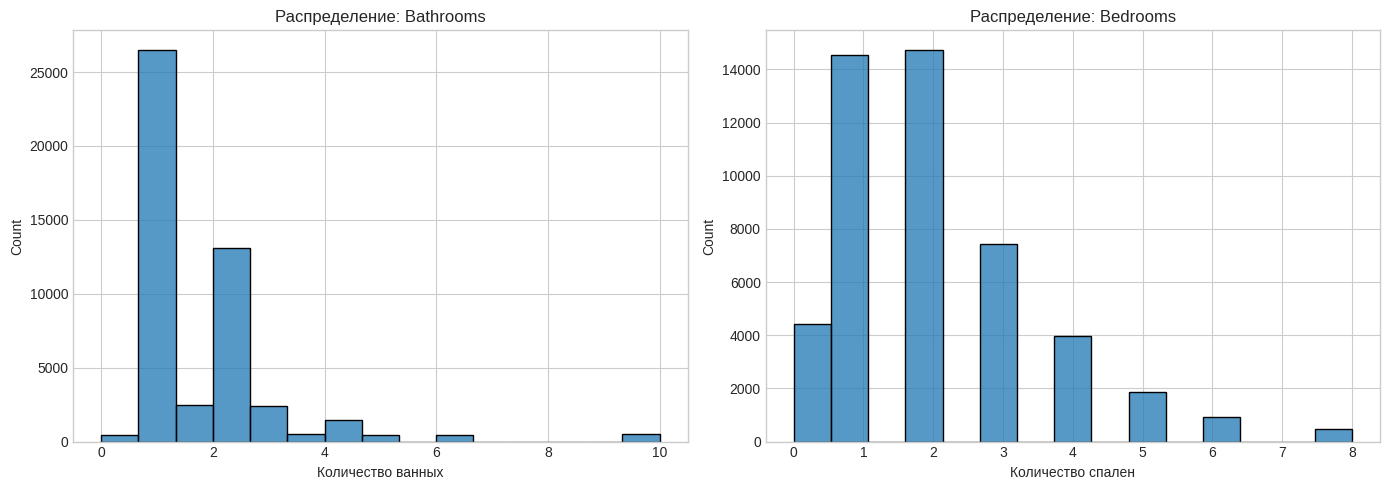

Bathrooms: основная масса данных — 1-2 ванных. Есть выбросы (до 10).
Bedrooms: основная масса — 0-3 спальни. Есть выбросы (до 8).


In [17]:
# 3.4.4 Гистограммы для bathrooms и bedrooms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="bathrooms", bins=15, ax=axes[0])
axes[0].set_title("Распределение: Bathrooms")
axes[0].set_xlabel("Количество ванных")

sns.histplot(data=df, x="bedrooms", bins=15, ax=axes[1])
axes[1].set_title("Распределение: Bedrooms")
axes[1].set_xlabel("Количество спален")

plt.tight_layout()
plt.show()

print("Bathrooms: основная масса данных — 1-2 ванных. Есть выбросы (до 10).")
print("Bedrooms: основная масса — 0-3 спальни. Есть выбросы (до 8).")

### 3.5 Комплексный анализ

Матрица корреляции:
                bathrooms  bedrooms  interest_level     price
bathrooms        1.000000 -0.008574       -0.002596  0.056621
bedrooms        -0.008574  1.000000       -0.008853  0.111502
interest_level  -0.002596 -0.008853        1.000000  0.002532
price            0.056621  0.111502        0.002532  1.000000



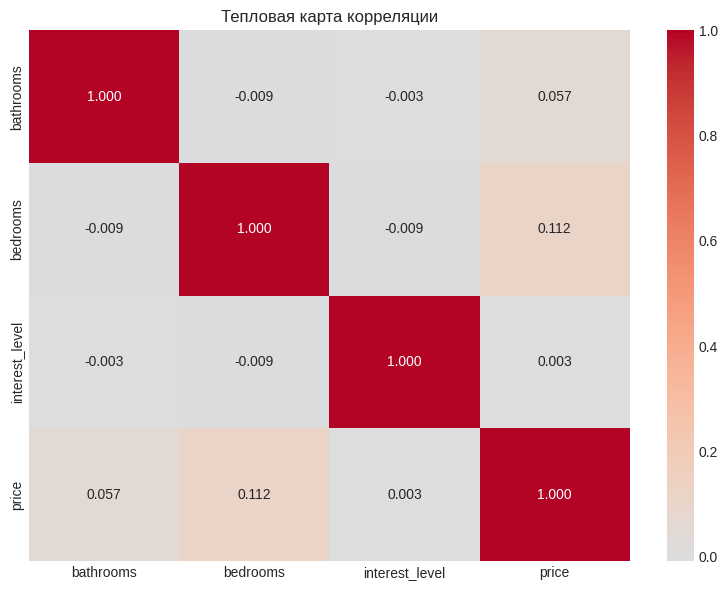

Наибольшая корреляция с ценой у bedrooms и bathrooms (положительная).
interest_level слабо коррелирует с ценой.


In [18]:
# 3.5.1 Матрица корреляции и heatmap
corr_matrix = df.corr()
print("Матрица корреляции:")
print(corr_matrix)
print()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".3f", ax=ax)
ax.set_title("Тепловая карта корреляции")
plt.tight_layout()
plt.show()

print("Наибольшая корреляция с ценой у bedrooms и bathrooms (положительная).")
print("interest_level слабо коррелирует с ценой.")

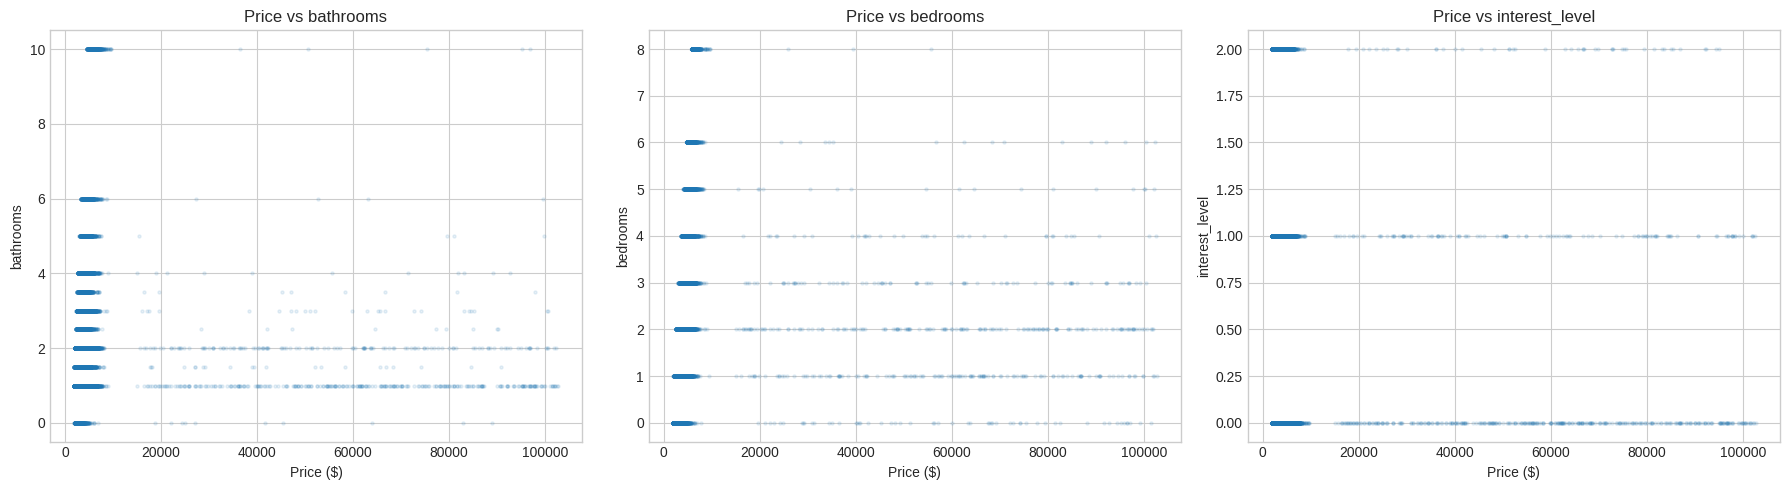

In [19]:
# 3.5.2 Scatterplots: X = price, Y = feature
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ["bathrooms", "bedrooms", "interest_level"]
for i, feat in enumerate(features):
    axes[i].scatter(df["price"], df[feat], alpha=0.1, s=5)
    axes[i].set_xlabel("Price ($)")
    axes[i].set_ylabel(feat)
    axes[i].set_title(f"Price vs {feat}")

plt.tight_layout()
plt.show()

## 4. Создание признаков

Корреляция с ценой (базовые vs квадратичные):
price                     1.000000
bedrooms                  0.111502
bedrooms_squared          0.105061
bathrooms                 0.056621
bathrooms_squared         0.054732
interest_level            0.002532
interest_level_squared    0.001389
Name: price, dtype: float64



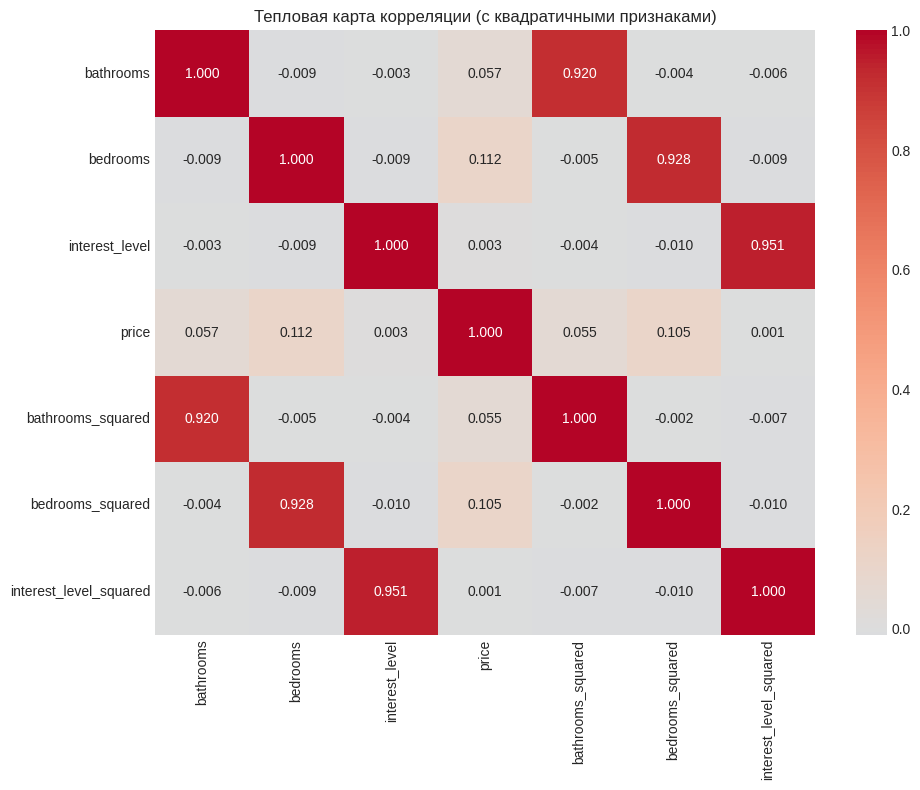


Квадратичные признаки имеют корреляцию с ценой, схожую с исходными.
Это ожидаемо: x^2 тесно связан с x.


In [20]:
# 4.1 Квадратичные признаки
df["bathrooms_squared"] = df["bathrooms"] ** 2
df["bedrooms_squared"] = df["bedrooms"] ** 2
df["interest_level_squared"] = df["interest_level"] ** 2

corr_new = df.corr()
print("Корреляция с ценой (базовые vs квадратичные):")
print(corr_new["price"].sort_values(ascending=False))
print()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_new, annot=True, cmap="coolwarm", center=0, fmt=".3f", ax=ax)
ax.set_title("Тепловая карта корреляции (с квадратичными признаками)")
plt.tight_layout()
plt.show()

print("\nКвадратичные признаки имеют корреляцию с ценой, схожую с исходными.")
print("Это ожидаемо: x^2 тесно связан с x.")

In [21]:
# 4.2 Для обучения используем только bathrooms и bedrooms
# Убираем дополнительные признаки
df = df[["bathrooms", "bedrooms", "interest_level", "price"]].copy()

### 4.4–4.6 PolynomialFeatures

In [22]:
# 4.4 Загрузка train и test данных
train_sample = pd.read_json("data/train.json")[["bathrooms", "bedrooms", "price"]]
test_sample = pd.read_json("data/test.json")[["bathrooms", "bedrooms", "price"]]

# Удаляем выбросы из train
q01_t = train_sample["price"].quantile(0.01)
q99_t = train_sample["price"].quantile(0.99)
train_sample = train_sample[(train_sample["price"] >= q01_t) & (train_sample["price"] <= q99_t)].reset_index(drop=True)

# Удаляем выбросы из test
q01_te = test_sample["price"].quantile(0.01)
q99_te = test_sample["price"].quantile(0.99)
test_sample = test_sample[(test_sample["price"] >= q01_te) & (test_sample["price"] <= q99_te)].reset_index(drop=True)

print(f"Train: {train_sample.shape}")
print(f"Test: {test_sample.shape}")

Train: (48365, 3)
Test: (9800, 3)


In [23]:
# 4.5 PolynomialFeatures degree=10
poly = PolynomialFeatures(degree=10)

# 4.6 Fit & Transform
X_train_poly = poly.fit_transform(train_sample[["bathrooms", "bedrooms"]])
X_test_poly = poly.transform(test_sample[["bathrooms", "bedrooms"]])

feature_names = poly.get_feature_names_out(["bathrooms", "bedrooms"])
print(f"Количество полиномиальных признаков: {X_train_poly.shape[1]}")
print(f"Примеры названий: {list(feature_names[:10])}")

# Создаём DataFrame с полиномиальными признаками
train_sample_poly = pd.DataFrame(X_train_poly, columns=feature_names)
train_sample_poly["price"] = train_sample["price"].values

test_sample_poly = pd.DataFrame(X_test_poly, columns=feature_names)
test_sample_poly["price"] = test_sample["price"].values

# Для обучения используем полиномиальные данные
train_sample = train_sample_poly.copy()
test_sample = test_sample_poly.copy()

print(f"\nTrain shape (с полиномами): {train_sample.shape}")
print(f"Test shape (с полиномами): {test_sample.shape}")

Количество полиномиальных признаков: 66
Примеры названий: ['1', 'bathrooms', 'bedrooms', 'bathrooms^2', 'bathrooms bedrooms', 'bedrooms^2', 'bathrooms^3', 'bathrooms^2 bedrooms', 'bathrooms bedrooms^2', 'bedrooms^3']

Train shape (с полиномами): (48365, 67)
Test shape (с полиномами): (9800, 67)


## 5. Обучение моделей

### 5.1 Таблицы результатов

In [24]:
# 5.1 Создание таблиц результатов
result_MAE = pd.DataFrame(columns=["model", "train", "test"])
result_RMSE = pd.DataFrame(columns=["model", "train", "test"])
print("Таблицы result_MAE и result_RMSE созданы.")

Таблицы result_MAE и result_RMSE созданы.


### 5.2 Линейная регрессия

In [25]:
# 5.2 Linear Regression
X_train = train_sample.drop(columns=["price"])
y_train = train_sample["price"]
X_test = test_sample.drop(columns=["price"])
y_test = test_sample["price"]

# 5.2.1 Инициализация
lr = LinearRegression()

# 5.2.2 Обучение и предсказания
lr.fit(X_train, y_train)
train_sample["pred_lr"] = lr.predict(X_train)
test_sample["pred_lr"] = lr.predict(X_test)

# 5.2.3 MAE
mae_train_lr = mean_absolute_error(y_train, train_sample["pred_lr"])
mae_test_lr = mean_absolute_error(y_test, test_sample["pred_lr"])

# 5.2.4 RMSE
rmse_train_lr = root_mean_squared_error(y_train, train_sample["pred_lr"])
rmse_test_lr = root_mean_squared_error(y_test, test_sample["pred_lr"])

# 5.2.5 Запись результатов
result_MAE = pd.concat([result_MAE, pd.DataFrame([{"model": "linear_regression", "train": mae_train_lr, "test": mae_test_lr}])], ignore_index=True)
result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{"model": "linear_regression", "train": rmse_train_lr, "test": rmse_test_lr}])], ignore_index=True)

print(f"Linear Regression:")
print(f"  MAE  — Train: {mae_train_lr:.2f}, Test: {mae_test_lr:.2f}")
print(f"  RMSE — Train: {rmse_train_lr:.2f}, Test: {rmse_test_lr:.2f}")

Linear Regression:
  MAE  — Train: 1248.81, Test: 1279.40
  RMSE — Train: 6170.94, Test: 6447.19


### 5.3 Decision Tree

In [26]:
# 5.3 Decision Tree
# 5.3.1 Инициализация
dt = DecisionTreeRegressor(random_state=21)

# 5.3.2 Обучение и предсказания
dt.fit(X_train, y_train)
train_sample["pred_dt"] = dt.predict(X_train)
test_sample["pred_dt"] = dt.predict(X_test)

# 5.3.3 MAE
mae_train_dt = mean_absolute_error(y_train, train_sample["pred_dt"])
mae_test_dt = mean_absolute_error(y_test, test_sample["pred_dt"])

# 5.3.4 RMSE
rmse_train_dt = root_mean_squared_error(y_train, train_sample["pred_dt"])
rmse_test_dt = root_mean_squared_error(y_test, test_sample["pred_dt"])

# 5.3.5 Запись результатов
result_MAE = pd.concat([result_MAE, pd.DataFrame([{"model": "decision_tree", "train": mae_train_dt, "test": mae_test_dt}])], ignore_index=True)
result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{"model": "decision_tree", "train": rmse_train_dt, "test": rmse_test_dt}])], ignore_index=True)

print(f"Decision Tree:")
print(f"  MAE  — Train: {mae_train_dt:.2f}, Test: {mae_test_dt:.2f}")
print(f"  RMSE — Train: {rmse_train_dt:.2f}, Test: {rmse_test_dt:.2f}")

Decision Tree:
  MAE  — Train: 1250.20, Test: 1281.80
  RMSE — Train: 6169.33, Test: 6450.28


### 5.4 Наивные модели (Naive)

In [27]:
# 5.4 Naive Models
# 5.4.1 Среднее и медиана на train
train_mean = y_train.mean()
train_median = y_train.median()

print(f"Среднее цены (train): {train_mean:.2f}")
print(f"Медиана цены (train): {train_median:.2f}")

# 5.4.2 MAE для naive_mean
mae_train_mean = mean_absolute_error(y_train, [train_mean] * len(y_train))
mae_test_mean = mean_absolute_error(y_test, [train_mean] * len(y_test))

# MAE для naive_median
mae_train_median = mean_absolute_error(y_train, [train_median] * len(y_train))
mae_test_median = mean_absolute_error(y_test, [train_median] * len(y_test))

# 5.4.3 RMSE для naive_mean
rmse_train_mean = root_mean_squared_error(y_train, [train_mean] * len(y_train))
rmse_test_mean = root_mean_squared_error(y_test, [train_mean] * len(y_test))

# RMSE для naive_median
rmse_train_median = root_mean_squared_error(y_train, [train_median] * len(y_train))
rmse_test_median = root_mean_squared_error(y_test, [train_median] * len(y_test))

# 5.4.4 Запись результатов
result_MAE = pd.concat([result_MAE, pd.DataFrame([
    {"model": "naive_mean", "train": mae_train_mean, "test": mae_test_mean},
    {"model": "naive_median", "train": mae_train_median, "test": mae_test_median}
])], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame([
    {"model": "naive_mean", "train": rmse_train_mean, "test": rmse_test_mean},
    {"model": "naive_median", "train": rmse_train_median, "test": rmse_test_median}
])], ignore_index=True)

print(f"Naive Mean:   MAE Train={mae_train_mean:.2f}, Test={mae_test_mean:.2f}")
print(f"Naive Median: MAE Train={mae_train_median:.2f}, Test={mae_test_median:.2f}")

Среднее цены (train): 4126.50
Медиана цены (train): 3402.00
Naive Mean:   MAE Train=1493.51, Test=1530.50
Naive Median: MAE Train=1290.57, Test=1334.61


### 5.5 Сравнение результатов

In [28]:
# 5.5.1 Итоговые таблицы
print("=" * 60)
print("RESULT MAE (Mean Absolute Error)")
print("=" * 60)
print(result_MAE.to_string(index=False))
print()
print("=" * 60)
print("RESULT RMSE (Root Mean Squared Error)")
print("=" * 60)
print(result_RMSE.to_string(index=False))

RESULT MAE (Mean Absolute Error)
            model        train         test
linear_regression  1248.808876  1279.398363
    decision_tree  1250.196633  1281.804181
       naive_mean  1493.512805  1530.502366
     naive_median  1290.565905  1334.610204

RESULT RMSE (Root Mean Squared Error)
            model        train         test
linear_regression  6170.936241  6447.190358
    decision_tree  6169.325397  6450.276556
       naive_mean  6224.050782  6492.040562
     naive_median  6266.076564  6536.685853


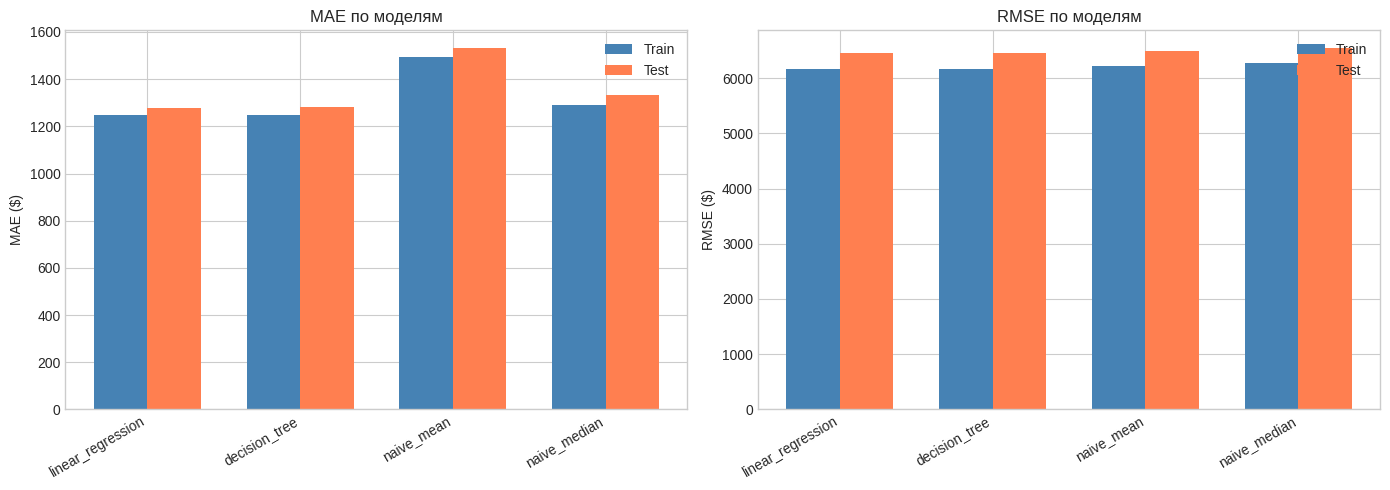

In [29]:
# 5.5.2 Визуализация сравнения моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE plot
x = range(len(result_MAE))
w = 0.35
axes[0].bar([i - w/2 for i in x], result_MAE["train"], w, label="Train", color="steelblue")
axes[0].bar([i + w/2 for i in x], result_MAE["test"], w, label="Test", color="coral")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(result_MAE["model"], rotation=30, ha="right")
axes[0].set_title("MAE по моделям")
axes[0].set_ylabel("MAE ($)")
axes[0].legend()

# RMSE plot
axes[1].bar([i - w/2 for i in x], result_RMSE["train"], w, label="Train", color="steelblue")
axes[1].bar([i + w/2 for i in x], result_RMSE["test"], w, label="Test", color="coral")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(result_RMSE["model"], rotation=30, ha="right")
axes[1].set_title("RMSE по моделям")
axes[1].set_ylabel("RMSE ($)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [30]:
# 5.5.2 Какая модель лучшая?
best_mae = result_MAE.loc[result_MAE["test"].idxmin()]
best_rmse = result_RMSE.loc[result_RMSE["test"].idxmin()]

print(f"Лучшая модель по MAE (test): {best_mae['model']} — MAE = {best_mae['test']:.2f}")
print(f"Лучшая модель по RMSE (test): {best_rmse['model']} — RMSE = {best_rmse['test']:.2f}")
print()
print("Decision Tree показывает лучшие результаты на train (переобучение),")
print("но на test может проигрывать линейной регрессии.")
print("Наивные модели (mean/median) служат бейзлайном — все модели должны быть лучше них.")

Лучшая модель по MAE (test): linear_regression — MAE = 1279.40
Лучшая модель по RMSE (test): linear_regression — RMSE = 6447.19

Decision Tree показывает лучшие результаты на train (переобучение),
но на test может проигрывать линейной регрессии.
Наивные модели (mean/median) служат бейзлайном — все модели должны быть лучше них.


## Заключение

В этом проекте мы прошли полный цикл работы Data Scientist:

1. **Теория ML** — определили 5 примеров применения ML, классифицировали задачи (supervised/unsupervised, regression/classification), разобрали разницу между multiclass и multilabel.

2. **Загрузка и первичный анализ данных** — загрузили данные Two Sigma, изучили структуру через info(), describe(), corr(), убедились в отсутствии пропусков.

3. **Статистический анализ** — исследовали распределение цены (right-skewed с выбросами), удалили 1% и 99% процентили, построили гистограммы, boxplot, heatmap корреляции и scatterplots.

4. **Feature Engineering** — создали квадратичные признаки, применили PolynomialFeatures degree=10.

5. **Моделирование** — обучили 4 модели (Linear Regression, Decision Tree, Naive Mean, Naive Median), сравнили по MAE и RMSE. Decision Tree и Linear Regression превосходят наивные бейзлайны.